In [ ]:
import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np

In [3]:
search = lk.search_lightcurve("Kepler-10",mission = "Kepler")
lc = search [:10].download_all().stitch()
lc_clean = lc.remove_outliers(sigma = 3)
lc_flat, trend = lc_clean.flatten(window_length = 101, polyorder = 2, return_trend = True)
print(lc_flat)

       time             flux      ...   pos_corr1      pos_corr2   
                                  ...      pix            pix      
------------------ -------------- ... -------------- --------------
200.32408500967722  9.9994302e-01 ... -8.9440849e-03  3.7062202e-02
 200.3247661127025  1.0001713e+00 ... -8.9426376e-03  3.7056953e-02
200.32544721572776  1.0000766e+00 ... -8.9411894e-03  3.7051704e-02
200.32612831898587  9.9974235e-01 ... -8.9397421e-03  3.7046455e-02
 200.3268094220184  9.9967900e-01 ... -8.9382939e-03  3.7041202e-02
 200.3274905250437  9.9984653e-01 ... -8.9368466e-03  3.7035953e-02
200.32817172830255  9.9991185e-01 ... -8.9353984e-03  3.7030704e-02
200.32885283132782  1.0000844e+00 ... -8.9339502e-03  3.7025455e-02
 200.3295339343531  1.0000614e+00 ... -8.9325029e-03  3.7020203e-02
               ...            ... ...            ...            ...
 598.2819913602871  1.0000472e+00 ... -3.2196606e-03 -5.1059730e-02
 598.2826723542385  9.9997854e-01 ... -3.2232974

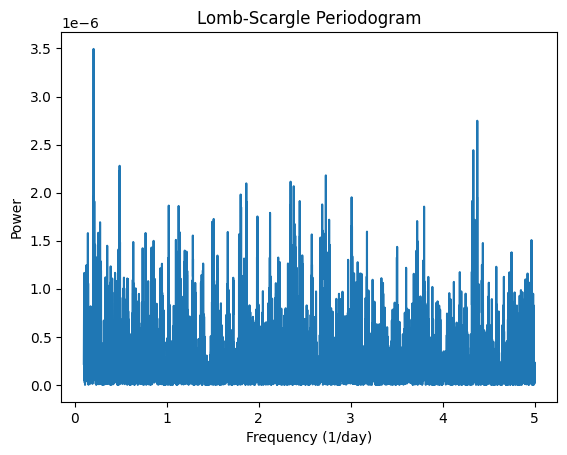

In [4]:
from astropy.timeseries import LombScargle

time = lc_flat.time.value
flux = lc_flat.flux.value

frequency, power = LombScargle(time, flux).autopower(minimum_frequency=0.1, maximum_frequency = 5.0)

plt.plot(frequency, power)
plt.xlabel("Frequency (1/day)")
plt.ylabel("Power")
plt.title("Lomb-Scargle Periodogram")
plt.show()

In [9]:
best_frequency = frequency[np.argmax(power)]
best_period = 1/best_frequency

print(f"Best frequency: {best_frequency:.4f} per day")

print(f"Best period: {best_period:.4f} days")

Best frequency: 0.2058 per day
Best period: 4.8582 days


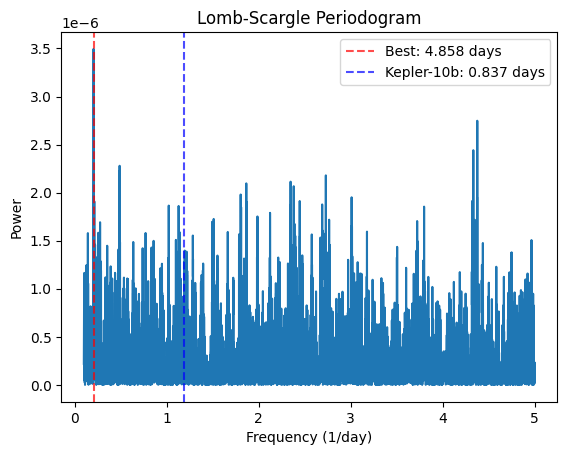

In [10]:
plt.plot(frequency, power)
plt.axvline(x=best_frequency, color='red', linestyle='--', alpha=0.7, label=f'Best: {best_period:.3f} days')
plt.axvline(x=1/0.8375, color='blue', linestyle='--', alpha=0.7, label='Kepler-10b: 0.837 days')
plt.xlabel("Frequency (1/day)")
plt.ylabel("Power")
plt.legend()
plt.title("Lomb-Scargle Periodogram")
plt.show()

/var/folders/gl/pb31_0s17tzfqmv3rstwv96c0000gn/T/ipykernel_53664/553580094.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


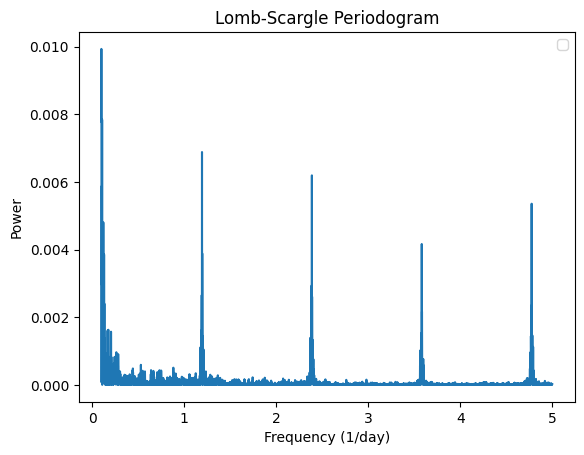

Best period: 9.9337 days


In [13]:
time = lc_clean.time.value
flux = lc_clean.flux.value

frequency, power = LombScargle(time, flux).autopower(minimum_frequency=0.1,
                                                       maximum_frequency=5.0)
best_frequency = frequency[np.argmax(power)]
best_period = 1/best_frequency

plt.plot(frequency, power)
#plt.axvline(x=best_frequency, color='red', linestyle='--', alpha=0.7, label=f'Best: {best_period:.3f} days')
#plt.axvline(x=1/0.8375, color='blue', linestyle='--', alpha=0.7, label='Kepler-10b: 0.837 days')

plt.xlabel("Frequency (1/day)")
plt.ylabel("Power")
plt.legend()
plt.title("Lomb-Scargle Periodogram")
plt.show()

print(f"Best period: {best_period:.4f} days")

The dark spots repeat at 0.1 frequency (9.934 day period) — that's the stellar rotation peak, 
the tallest one on the left.
The 1.19 peak is the planet.
- 0.1 = spots rotating in and out of view every 9.934 days → irrelevant to our work
- 1.19 = planet blocking light every 0.837 days → this is what we want

In [14]:
best_planet_frequency = frequency[(frequency > 1.0) & (frequency < 1.4)][np.argmax(power[(frequency > 1.0) & (frequency < 1.4)])]
best_planet_period = 1/best_planet_frequency
print(f"Period from periodogram: {best_planet_period:.4f} days")

Period from periodogram: 0.8374 days
